# Wind Turbine Early Fault Detection — EDA & Modeling
### Wind Farm A (CARE benchmark, Kaggle mirror)

This notebook walks through:
1. Loading a Wind Farm A sub-dataset
2. Understanding the schema (status IDs, train/prediction split, event labels)
3. Exploratory data analysis (power curve, sensor drift, missingness)
4. Feature engineering
5. Training a per-turbine Normal Behavior Model (Isolation Forest baseline,
   then optionally an autoencoder)
6. Scoring the prediction period and visualizing the anomaly score vs the
   documented fault onset
7. Evaluating with CARE-style Coverage / Accuracy / Reliability / Earliness
8. Persisting a trained model and calling it through the serving API

**Before running:** download the dataset from
[Kaggle](https://www.kaggle.com/datasets/azizkasimov/wind-turbine-scada-data-for-early-fault-detection),
extract the `Wind Farm A` folder, and point `RAW_DIR` below at it. If you
just want to see the pipeline run, leave `USE_SYNTHETIC = True` to use the
bundled synthetic-but-schema-accurate sample data.


In [4]:
df=pd.read_csv(r'D:\OneDrive - SoftDEL Systems Pvt. Ltd\Data_of_C\wind_turbine_pipeline\wind_turbine_pipeline\data\raw\Wind Farm A\comma_0.csv')
df.columns

Index(['time_stamp', 'asset_id', 'id', 'train_test', 'status_type_id',
       'sensor_0_avg', 'sensor_1_avg', 'sensor_2_avg', 'wind_speed_3_avg',
       'wind_speed_4_avg', 'wind_speed_3_max', 'wind_speed_3_min',
       'wind_speed_3_std', 'sensor_5_avg', 'sensor_5_max', 'sensor_5_min',
       'sensor_5_std', 'sensor_6_avg', 'sensor_7_avg', 'sensor_8_avg',
       'sensor_9_avg', 'sensor_10_avg', 'sensor_11_avg', 'sensor_12_avg',
       'sensor_13_avg', 'sensor_14_avg', 'sensor_15_avg', 'sensor_16_avg',
       'sensor_17_avg', 'sensor_18_avg', 'sensor_18_max', 'sensor_18_min',
       'sensor_18_std', 'sensor_19_avg', 'sensor_20_avg', 'sensor_21_avg',
       'sensor_22_avg', 'sensor_23_avg', 'sensor_24_avg', 'sensor_25_avg',
       'sensor_26_avg', 'reactive_power_27_avg', 'reactive_power_27_max',
       'reactive_power_27_min', 'reactive_power_27_std',
       'reactive_power_28_avg', 'reactive_power_28_max',
       'reactive_power_28_min', 'reactive_power_28_std', 'power_29_avg',
      

In [1]:
import sys
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src import config, data_loader, features, model as model_module, evaluation

pd.set_option('display.max_columns', 30)
plt.rcParams['figure.figsize'] = (11, 4)


Matplotlib is building the font cache; this may take a moment.


In [2]:
# ---- Configuration ----
USE_SYNTHETIC = True   # set False once you've downloaded the real Kaggle data

if USE_SYNTHETIC:
    from tests.make_synthetic_data import build_synthetic_farm
    RAW_DIR = config.PROJECT_ROOT / "data" / "raw" / "Wind Farm A"
    if not RAW_DIR.exists():
        build_synthetic_farm(RAW_DIR)
else:
    RAW_DIR = config.RAW_DATA_DIR  # edit in src/config.py, or override here directly

paths = data_loader.discover_subdatasets(RAW_DIR)
print(f"Found {len(paths)} sub-datasets:")
for p in paths:
    print(" -", p.name)


Found 22 sub-datasets:
 - comma_0.csv
 - comma_10.csv
 - comma_13.csv
 - comma_14.csv
 - comma_17.csv
 - comma_22.csv
 - comma_24.csv
 - comma_25.csv
 - comma_26.csv
 - comma_3.csv
 - comma_38.csv
 - comma_40.csv
 - comma_42.csv
 - comma_45.csv
 - comma_51.csv
 - comma_68.csv
 - comma_69.csv
 - comma_71.csv
 - comma_72.csv
 - comma_73.csv
 - comma_84.csv
 - comma_92.csv


## 1. Load one anomaly sub-dataset and inspect the schema

In [3]:
# Filenames are bare integers (e.g. "3.csv") with no label in the name
# itself -- the real Wind Farm A structure. The label lives in the shared
# event_info file, so load each and check is_anomaly rather than pattern-
# matching the filename.
loaded = [data_loader.load_subdataset(p) for p in paths]
anomaly_subs = [s for s in loaded if s.is_anomaly]
normal_subs = [s for s in loaded if not s.is_anomaly]

sub = anomaly_subs[0]
print("Sub-dataset:", sub.name)
print("Asset:", sub.asset_id, "| event_label:", sub.event_label)
print("event_start:", sub.event_start, "| event_end (fault onset):", sub.event_end)
print("event_description:", sub.event_description)
print("Shape:", sub.df.shape)
sub.df.head()


No event metadata found for comma_0.csv (checked ['D:\\OneDrive - SoftDEL Systems Pvt. Ltd\\Data_of_C\\wind_turbine_pipeline\\wind_turbine_pipeline\\data\\raw\\Wind Farm A', 'D:\\OneDrive - SoftDEL Systems Pvt. Ltd\\Data_of_C\\wind_turbine_pipeline\\wind_turbine_pipeline\\data\\raw'] for ('comma_event_info.csv', 'event_info.csv', 'event_info.json', 'metadata.json'), normalized id '0') — event_label/asset_id will be None, which will break is_anomaly and evaluation for this dataset.
No event metadata found for comma_10.csv (checked ['D:\\OneDrive - SoftDEL Systems Pvt. Ltd\\Data_of_C\\wind_turbine_pipeline\\wind_turbine_pipeline\\data\\raw\\Wind Farm A', 'D:\\OneDrive - SoftDEL Systems Pvt. Ltd\\Data_of_C\\wind_turbine_pipeline\\wind_turbine_pipeline\\data\\raw'] for ('comma_event_info.csv', 'event_info.csv', 'event_info.json', 'metadata.json'), normalized id '10') — event_label/asset_id will be None, which will break is_anomaly and evaluation for this dataset.
No event metadata found fo

IndexError: list index out of range

In [4]:
print("Rows by split:")
print(sub.df[config.SPLIT_COL].value_counts())
print()
print("Rows by status_type_id (0/2 = normal, else abnormal):")
print(sub.df[config.STATUS_COL].value_counts().sort_index())


Rows by split:
train_test
train         52560
prediction     5760
Name: count, dtype: int64

Rows by status_type_id (0/2 = normal, else abnormal):
status_type_id
0    58176
4      144
Name: count, dtype: int64


## 2. Power curve sanity check

Power should rise roughly as wind-speed cubed up to rated power, then flatten.
Points that fall well below the expected curve for their wind speed are a
classic early symptom of degradation (blade fouling, pitch misalignment,
gearbox friction, etc.).

Power column: power | Wind speed column: wind_speed


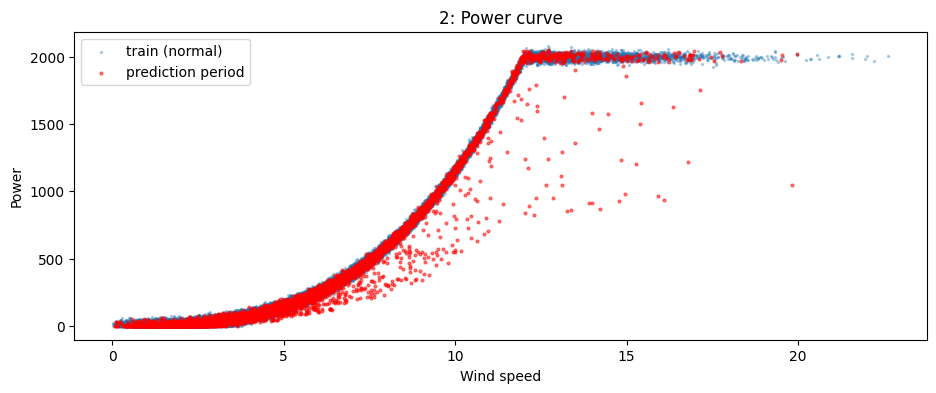

In [5]:
cols = features.identify_columns(sub.df)
power_col, wind_col = cols['power'][0], cols['wind_speed'][0]
print("Power column:", power_col, "| Wind speed column:", wind_col)

fig, ax = plt.subplots()
normal_train = sub.train[sub.train[config.STATUS_COL].isin(config.NORMAL_STATUS_IDS)]
ax.scatter(normal_train[wind_col], normal_train[power_col], s=2, alpha=0.3, label='train (normal)')
pred = sub.prediction
ax.scatter(pred[wind_col], pred[power_col], s=4, alpha=0.5, color='red', label='prediction period')
ax.set_xlabel('Wind speed'); ax.set_ylabel('Power'); ax.legend(); ax.set_title(f'{sub.name}: Power curve')
plt.show()


## 3. Feature engineering

In [6]:
df_feat, feature_cols, power_curve_reference = features.engineer_features(sub.df)
print(f"{len(feature_cols)} model-ready numeric features engineered (rolling stats + power-curve residual).")
df_feat[feature_cols].describe().T.head(10)


156 model-ready numeric features engineered (rolling stats + power-curve residual).


,count,mean,std,min,25%,50%,75%,max
power,58320.0,463.248926,558.697062,0.000000,62.025733,229.751712,641.842290,2083.338485
wind_speed,58320.0,6.191978,3.237751,0.028523,3.733635,5.837953,8.221569,22.625142
sensor_0,58320.0,14.461261,2.067397,6.089287,13.067124,14.434998,15.807141,27.013502
sensor_1,58320.0,86.733648,2.061039,78.198661,85.350477,86.700970,88.075368,98.985694
sensor_2,58320.0,90.813476,2.064774,82.706129,89.433426,90.785835,92.153462,103.033867
sensor_3,58320.0,81.877617,2.009819,73.132608,80.525681,81.881339,83.235269,91.124442
sensor_4,58320.0,50.064764,2.006244,41.851989,48.707017,50.064704,51.419241,58.289909
sensor_5,58320.0,96.075972,1.992595,87.246174,94.738440,96.077456,97.418108,106.627151
sensor_6,58320.0,98.320185,2.006367,90.221896,96.962769,98.316556,99.677016,107.071055
sensor_7,58320.0,49.568619,2.011959,41.132060,48.213075,49.580352,50.924874,58.147329


## 4. Train a per-turbine Normal Behavior Model

We fit on the **training-period, normal-status-only** rows — this is
important: including abnormal-status training rows (derating, service mode)
would teach the model that degraded behavior is normal.

In [7]:
label = features.build_label(df_feat)
df_feat = df_feat.assign(_status_label=label)

train_mask = df_feat[config.SPLIT_COL] == config.TRAIN_VALUE
normal_train_mask = train_mask & (df_feat['_status_label'] == 0)
train_full = df_feat.loc[normal_train_mask, feature_cols]

n_val = max(1, int(len(train_full) * config.VALIDATION_FRACTION))
train_fit, train_val = train_full.iloc[:-n_val], train_full.iloc[-n_val:]
print(f"Fitting on {len(train_fit)} rows, calibrating threshold on {len(train_val)} held-out normal rows.")

clf = model_module.IsolationForestDetector()
clf.fit(train_fit)

val_scores = clf.score(train_val)
threshold = model_module.calibrate_threshold(val_scores)
print(f"Calibrated anomaly threshold (99th pct of held-out normal scores): {threshold:.4f}")


Fitting on 42048 rows, calibrating threshold on 10512 held-out normal rows.


Calibrated anomaly threshold (99th pct of held-out normal scores): 0.0005


> **Want the autoencoder instead?** Uncomment the block below (requires
> `pip install tensorflow --break-system-packages`). It's the approach used
> in the original CARE paper's own benchmark and tends to model nonlinear
> sensor interactions better than Isolation Forest, at the cost of needing
> more data and a GPU/CPU-minutes budget per turbine.
>
> ```python
> clf = model_module.AutoencoderDetector(input_dim=len(feature_cols))
> clf.fit(train_fit, X_val=train_val, epochs=40, verbose=1)
> val_scores = clf.score(train_val)
> threshold = model_module.calibrate_threshold(val_scores)
> ```


## 5. Score the prediction period and visualize against the fault onset

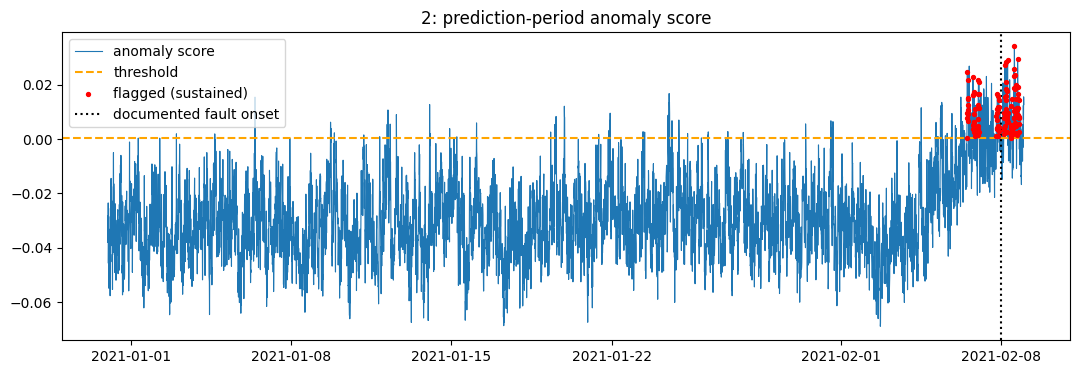

First sustained alarm: 2021-02-06 12:10:00  ->  35.8 hours before documented fault onset


In [8]:
pred_df = df_feat.loc[df_feat[config.SPLIT_COL] == config.PREDICTION_VALUE]
pred_scores = clf.score(pred_df[feature_cols])
pred_flags = model_module.scores_to_events(pred_scores, threshold)

fig, ax = plt.subplots(figsize=(13, 4))
ax.plot(pred_df[config.TIME_COL], pred_scores, lw=0.8, label='anomaly score')
ax.axhline(threshold, color='orange', ls='--', label='threshold')
flagged_times = pred_df[config.TIME_COL][pred_flags == 1]
ax.scatter(flagged_times, pred_scores[pred_flags == 1], color='red', s=8, label='flagged (sustained)', zorder=5)
if sub.event_end is not None:
    ax.axvline(sub.event_end, color='black', ls=':', label='documented fault onset')
ax.set_title(f'{sub.name}: prediction-period anomaly score')
ax.legend(loc='upper left')
plt.show()

if len(flagged_times) > 0 and sub.event_end is not None:
    lead_hours = (sub.event_end - flagged_times.min()).total_seconds() / 3600
    print(f"First sustained alarm: {flagged_times.min()}  ->  {lead_hours:.1f} hours before documented fault onset")


## 6. Evaluate with CARE-style metrics for this one sub-dataset

In [9]:
result = evaluation.evaluate_subdataset(
    name=sub.name,
    is_anomaly=sub.is_anomaly,
    status_ids=pred_df[config.STATUS_COL],
    predicted_flags=pred_flags,
    timestamps=pred_df[config.TIME_COL],
    fault_onset=sub.event_end,
)
result


SubDatasetResult(name='2', is_anomaly=True, coverage=0.046296296296296294, accuracy=None, reliability=0.2, earliness_hours=35.833333333333336, n_flagged_points=54, n_eval_points=5616)

## 7. Run across ALL sub-datasets

This mirrors `src/run_pipeline.py` — same logic, but interactive so you can
inspect intermediate results. For a full production run, use the script:

```bash
python -m src.run_pipeline --model isolation_forest
```


In [10]:
from src.run_pipeline import process_one

all_results, all_diag = [], []
for p in paths:
    s = data_loader.load_subdataset(p)
    try:
        res, diag = process_one(s, model_kind='isolation_forest')
        all_results.append(res)
        diag['dataset'] = s.name
        all_diag.append(diag)
    except Exception as e:
        print(f"FAILED on {p.name}: {e}")

report_df = evaluation.aggregate_results(all_results)
report_df


,dataset,is_anomaly,coverage,accuracy,reliability,earliness_hours,n_flagged_points,n_eval_points
0,0,False,NaN,1.000000,NaN,NaN,0,4320
1,1,False,NaN,0.996991,NaN,NaN,13,4320
2,2,True,0.046296,NaN,0.20000,35.833333,54,5616
3,3,True,0.129310,NaN,0.09434,852.500000,162,5616


In [11]:
summary = evaluation.summarize(report_df)
for k, v in summary.items():
    print(f"{k:28s} {v}")


n_anomaly_datasets           2
n_normal_datasets            2
mean_coverage                0.08780332056194126
mean_reliability             0.14716981132075474
mean_earliness_hours         444.1666666666667
mean_accuracy_on_normal      0.9984953703703704
care_like_composite          0.5583671255632665


## 8. Persisting a trained model and calling it through the serving API

`src/run_pipeline.py --save-models` fits and saves one bundle per turbine
(detector + threshold + feature column order + power-curve reference) to
`models/`. `src/serve.py` (a FastAPI app) loads those bundles and exposes a
`/predict` endpoint. Below: save this notebook's already-fitted model, then
call it exactly the way an external caller would — over HTTP.

**Run this in a terminal first** (can't background a long-running server
from inside a notebook cell cleanly):
```bash
python -m src.run_pipeline --model isolation_forest --save-models
uvicorn src.serve:app --reload --port 8000
```
Then run the cell below.

In [12]:
import joblib

# Save this notebook's exact fitted model + threshold + power curve
# reference as a bundle — the same format run_pipeline.py --save-models
# produces, and the same format src/serve.py expects to load.
bundle = {
    "detector": clf,
    "feature_cols": feature_cols,
    "threshold": threshold,
    "power_curve_reference": power_curve_reference,
    "asset_id": sub.asset_id,
    "dataset_name": sub.name,
    "model_kind": "isolation_forest",
    "min_event_length": config.MIN_EVENT_LENGTH,
}
config.MODEL_DIR.mkdir(parents=True, exist_ok=True)
joblib.dump(bundle, config.MODEL_DIR / f"{sub.name}.joblib")
print(f"Saved {sub.name}.joblib to {config.MODEL_DIR}")


Saved 2.joblib to /home/claude/wind_turbine_pipeline/models


In [13]:
import json
import urllib.request

# Build a request payload the way a real caller would: a window of recent
# raw readings (>= 6h / 36 points so rolling features are meaningful).
window = sub.prediction.tail(40).copy()
window[config.TIME_COL] = window[config.TIME_COL].astype(str)
drop_cols = [c for c in (config.ID_COL, config.ASSET_COL, config.SPLIT_COL, config.STATUS_COL)
             if c in window.columns]
readings = window.drop(columns=drop_cols).to_dict('records')

req = urllib.request.Request(
    f"http://localhost:8000/predict/{sub.name}",
    data=json.dumps({"readings": readings}).encode(),
    headers={"Content-Type": "application/json"},
    method="POST",
)
try:
    with urllib.request.urlopen(req, timeout=10) as resp:
        print(json.loads(resp.read()))
except Exception as e:
    print(f"Couldn't reach the API — is `uvicorn src.serve:app --port 8000` running? ({e})")


{'dataset_name': '2', 'asset_id': 'WT100', 'latest_timestamp': '2021-02-08 23:50:00', 'anomaly_score': 0.012656737621151992, 'threshold': 0.000477043784405064, 'flagged': True, 'min_event_length': 6, 'n_readings_used': 40, 'warning': None}


Note the response's `flagged` field is a **single-point** comparison
against the threshold — it doesn't apply the same sustained-run smoothing
(`MIN_EVENT_LENGTH` consecutive points) that the offline evaluation above
does. The response includes `min_event_length` so a consuming system can
apply that same rule itself before paging anyone. See the docstring at the
top of `src/serve.py` for the full reasoning.

## Notes for productionizing

**Already built and tested** (this session): model persistence (joblib
bundles with a fit-once power-curve reference, avoiding train/serve skew),
a FastAPI serving layer with API-key auth, a Dockerfile, and a CI smoke
test that trains, saves, serves, and calls the API on every push.

**Still worth doing, roughly in order:**
- **Hosting**: for an internal API, check whether your company already has
  an AWS/Azure/GCP account this should land in — that answer picks the
  specific service (e.g. ECS/Cloud Run/Container Apps) and, more
  importantly, whatever auth/networking standard your org already uses. If
  there's no existing cloud footprint yet, a single small VM running the
  Docker container behind a reverse proxy is a reasonable minimal-ops start
  for a handful of internal callers.
- **Auth upgrade**: the API's single shared `X-API-Key` is fine for a first
  internal version; move to per-caller keys or your company's SSO/OAuth
  gateway once more than one team depends on it.
- **Sustained-alert smoothing**: the API scores one point at a time (see
  the note in section 8) — whatever calls it should apply the same
  `min_event_length` consecutive-flags rule the offline evaluation uses,
  or you'll get noisier alerts than the Reliability metric suggests.
- **Per-turbine models**: this notebook and pipeline fit one model per
  turbine/sub-dataset, matching how the CARE dataset (and most real SCADA
  deployments) are structured. If your fleet has many turbines of the same
  type, consider a shared model with turbine ID as a feature instead —
  fewer models to maintain, but you lose some turbine-specific nuance.
- **Retraining cadence**: seasonal effects matter (this data spans full
  years for a reason). Retrain training-window models at least seasonally,
  or use a rolling window — and re-run `--save-models` each time.
- **Model storage**: the Dockerfile currently bakes `models/` into the
  image (simplest to start with, fully reproducible). Once you have more
  than a couple of turbines, externalize model loading — mount a volume or
  pull from object storage at container startup — so retraining doesn't
  require a full image rebuild.
- **Next model upgrades**: LSTM/Transformer autoencoders, or a proper
  survival/RUL (remaining-useful-life) model, tend to outperform the dense
  autoencoder baseline here on this exact dataset in published work —
  worth trying once the current system is proven out end to end.
